In [1]:
import numpy as np 
import pandas as pd

import matplotlib
from matplotlib import transforms
#matplotlib.use("pgf")
matplotlib.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
    }
)
import matplotlib.pyplot as plt 
import scienceplots

from scipy.interpolate import splprep, splev
from scipy.interpolate import CubicSpline

In [2]:
plt.style.use(["science"])

In [3]:
textwidth = 6.202
aspect_ratio = 6/8
scale = 1.0
width = textwidth * scale
height = width * aspect_ratio
def fig(height_mul=1):
    return plt.figure(figsize=(width, height * height_mul))

In [4]:
def legend(*args, **kwargs):
    l = plt.legend(fancybox=False, edgecolor="black", *args, **kwargs)
    l.get_frame().set_linewidth(0.5)

In [5]:
p_taps = pd.read_excel("SLT practical coordinates.xlsx", sheet_name="Sheet1", names=['idx', 'x', 'y'], index_col=False, header=1)
p_taps.head()

/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/3904201115.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  p_taps = pd.read_excel("SLT practical coordinates.xlsx", sheet_name="Sheet1", names=['idx', 'x', 'y'], index_col=False, header=1)


,idx,x,y
0,P001,0.00000,0.00000
1,P002,0.35626,0.77154
2,P003,1.33331,1.60115
3,P004,3.66108,2.87759
4,P005,7.29220,4.15707


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


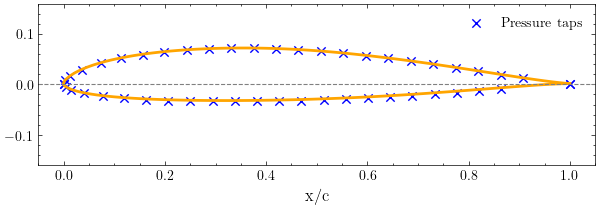

In [6]:
def plot_airfoil_with_c(airfoil, c):
    x, y = airfoil.x * c, airfoil.y * c
    
    te_index = np.argmin(x)

    x_upper = np.array(list(reversed(x[:te_index + 1])))
    y_upper = np.array(list(reversed(y[:te_index + 1])))

    x_lower = x[te_index:]
    y_lower = y[te_index:]

    cs_upper = CubicSpline(x_upper, y_upper)
    cs_lower = CubicSpline(x_lower, y_lower)

    chord = max(p_taps['x']) - min(p_taps['x'])

    fig(0.5)
    plt.plot(x_upper, cs_upper(x_upper), linewidth=2, color="orange")
    plt.plot(x_lower, cs_lower(x_lower), linewidth=2, color="orange")

    plt.scatter(p_taps.x / chord, p_taps.y / chord, color="blue", marker="x", label="Pressure taps")

    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Chord line
    plt.gca().set_aspect('equal', adjustable='datalim')
    legend()
    plt.xlabel("x/c", fontsize=12)

    plt.ylim((-0.1, 0.1))

    plt.tight_layout()

    plt.savefig("airfoil.pgf", format="pgf")

    plt.show()

sd6060 = pd.read_table("SD6060-104-88_180.dat", sep='\\s+', skiprows=[0], names=['x', 'y'], index_col=False)
plot_airfoil_with_c(sd6060, 1)

In [7]:
raw_2d = pd.read_csv("raw_2D.txt", sep='\\s+', index_col=False)
raw_2d = raw_2d.iloc[1:]
raw_2d = raw_2d.drop(columns=['Run_nr', 'Time'])
raw_2d = raw_2d.astype(float)
raw_2d = raw_2d.groupby('Alpha').mean()
raw_2d = raw_2d.reset_index()
raw_2d.head()

,Alpha,Delta_Pb,P_bar,T,rpm,rho,P001,P002,P003,P004,...,P104,P105,P106,P107,P108,P109,P110,P111,P112,P113
0,-5.0,99.800,1026.08,20.740,744.840,1.2160,-42.900,148.770,172.91,106.780,...,9.340,10.720,11.000,10.860,10.89,8.24,-0.030,0.00,-0.05,-0.01
1,-4.0,98.440,1026.11,20.750,745.010,1.2160,10.010,150.640,155.67,83.150,...,9.670,11.120,11.260,11.000,10.98,9.21,-0.120,-0.03,-0.03,-0.02
2,-3.0,96.950,1026.13,20.740,744.970,1.2160,79.750,148.420,135.70,59.800,...,10.260,10.940,10.970,10.660,10.64,9.31,0.140,-0.04,-0.03,-0.02
3,-2.0,98.325,1026.32,20.995,744.955,1.2155,133.620,138.725,111.65,38.100,...,10.565,10.845,10.315,10.395,10.68,9.30,0.200,-0.04,-0.05,-0.05
4,-1.0,98.630,1026.29,20.995,744.975,1.2155,171.215,120.975,84.35,16.955,...,10.595,10.535,10.545,10.400,10.52,9.51,-0.235,-0.04,-0.05,-0.06


In [8]:
df_3d = pd.read_csv('raw_3D.txt', sep='\t')
df_3d = df_3d.drop(0)
df_3d = df_3d.apply(lambda x: x.str.strip()).apply(pd.to_numeric, errors='coerce')
df_3d.columns = df_3d.columns.str.strip()
df_3d.head()

,Run_nr,Time,Alpha,Delta_Pb,P_bar,T,Fx,Fy,Fz,rpm,Rho
1,1,NaN,-5.0,98.13,1026.82,21.46,0.274,-2.978,0.709,748.3,1.214
2,2,NaN,-4.0,98.96,1026.73,21.46,0.207,-1.858,0.724,747.9,1.214
3,3,NaN,-3.0,98.80,1026.80,21.47,0.176,-0.984,0.742,748.4,1.214
4,4,NaN,-2.0,99.98,1026.78,21.48,0.177,-0.268,0.748,748.2,1.214
5,5,NaN,-1.0,98.74,1026.80,21.48,0.176,0.627,0.757,748.1,1.214


In [9]:
rho = 1.226

p_t_inf = raw_2d['P097'].values
p_s_inf = raw_2d['P110'].values

delta_p_2d = raw_2d['Delta_Pb'].values
delta_p_3d = df_3d['Delta_Pb'].values

q_inf_2d = 0.211804 + 1.928442 * delta_p_2d + 1.879374 * 10**(-4) * delta_p_2d**2
q_inf_3d = 0.211804 + 1.928442 * delta_p_3d + 1.879374 * 10**(-4) * delta_p_3d**2

u_inf_2d = np.sqrt(2 * q_inf_2d / rho)
u_inf_3d = np.sqrt(2 * q_inf_3d / rho)
u_inf_2d.mean(), u_inf_3d.mean()

(np.float64(17.62673327938336), np.float64(17.632345402906456))

In [10]:
def velocity_from_bernoulli(p_t, p_s):
    return np.sqrt(2 * (p_t - p_s) / rho)

In [11]:
p_taps_names = p_taps.idx.values.astype(str)
p_taps_names

array(['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008',
       'P009', 'P010', 'P011', 'P012', 'P013', 'P014', 'P015', 'P016',
       'P017', 'P018', 'P019', 'P020', 'P021', 'P022', 'P023', 'P024',
       'P025', 'P026', 'P027', 'P028', 'P029', 'P030', 'P031', 'P032',
       'P033', 'P034', 'P035', 'P036', 'P037', 'P038', 'P039', 'P040',
       'P041', 'P042', 'P043', 'P044', 'P045', 'P046', 'P047', 'P048',
       'P049'], dtype='<U4')

In [12]:
raw_2d.Alpha

0     -5.000
1     -4.000
2     -3.000
3     -2.000
4     -1.000
5     -0.000
6      1.000
7      2.000
8      3.000
9      4.000
10     5.000
11     6.000
12     7.000
13     8.000
14     9.000
15     9.500
16    10.000
17    10.250
18    10.500
19    10.750
20    11.000
21    11.250
22    11.500
23    11.750
24    12.000
25    12.250
26    12.500
27    12.750
28    13.000
29    13.126
30    13.250
31    13.500
32    13.750
33    14.000
34    14.250
35    14.500
36    14.750
37    15.000
38    15.500
39    16.000
40    16.500
41    17.000
42    18.000
43    19.000
44    20.000
Name: Alpha, dtype: float64

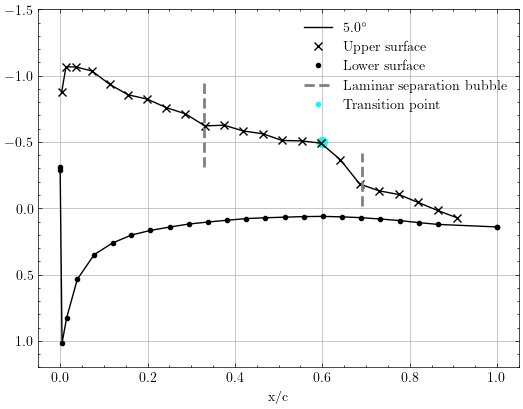

In [13]:
fig()

# make dicts from alpha to x, C_p dist
alpha_to_x_cp = {}

# 0, 10, 20, 30, 44

for i, row in raw_2d.iloc[[ 10 ]].iterrows():
    for p_tap in p_taps_names:
        p = row[p_tap]
        C_p = p / q_inf_2d[i]

        x = p_taps[p_taps.idx == p_tap].x.values[0]
        y = p_taps[p_taps.idx == p_tap].y.values[0]

        if y <= 0:
            alpha_to_x_cp.setdefault(row.Alpha, ([], [], [], []))[0].append(x / 100)
            alpha_to_x_cp.setdefault(row.Alpha, ([], [], [], []))[1].append(C_p)
        else:
            alpha_to_x_cp.setdefault(row.Alpha, ([], [], [], []))[2].append(x / 100)
            alpha_to_x_cp.setdefault(row.Alpha, ([], [], [], []))[3].append(C_p)

colors = ['black', 'green', 'blue']
linestyles = ["-", "--", "-.", ":", "-"]

for i, (alpha, (x_lower, C_p_lower, x_upper, C_p_upper)) in enumerate(alpha_to_x_cp.items()):
    x_lower, C_p_lower = zip(*sorted(zip(x_lower, C_p_lower)))
    x_upper, C_p_upper = zip(*sorted(zip(x_upper, C_p_upper)))
    
    color = colors[list(alpha_to_x_cp.keys()).index(alpha)]
    linestyle = linestyles[list(alpha_to_x_cp.keys()).index(alpha)]

    plt.plot(x_lower, C_p_lower, color=color, marker=".", linestyle=linestyle)
    plt.plot(x_upper, C_p_upper, color=color, marker="x", linestyle=linestyle)
    
# vertical lines at x=0.33, 0.46 and 0.51
plt.axvline(0.33, ymin=0.56, ymax=0.8, color='gray', linestyle='--', linewidth=2)
# plt.axvline(0.6, color='gray', linestyle='--', linewidth=1)
plt.scatter(0.6, -0.5, label="Transition point", color='cyan', marker='.', s=200)
plt.axvline(0.69, ymin=0.45, ymax=0.6, color='gray', linestyle='--', linewidth=2)

# custom legend with just line and color
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, linestyle=linestyle, label=f"{alpha}$^\\circ$") for alpha, linestyle, color in zip(alpha_to_x_cp.keys(), linestyles, colors)]
# add X for upper and . for lower in legend as labels
legend_elements += [Line2D([0], [0], color='black', marker='x', linestyle='None', label='Upper surface'),
                    Line2D([0], [0], color='black', marker='.', linestyle='None', label='Lower surface')]


legend_elements += [Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Laminar separation bubble')]
legend_elements += [Line2D([0], [0], color='cyan', marker='.', linestyle='None', label='Transition point')]

legend(handles=legend_elements)

# plt.legend(handles=legend_elements, loc='lower right')

plt.ylim(-1.5, 1.2)
plt.grid()
plt.xlabel("x/c")
# legend()
plt.gca().invert_yaxis()
plt.savefig("C_p.pgf", format="pgf")
plt.show()

<>:66: SyntaxWarning: invalid escape sequence '\c'
<>:66: SyntaxWarning: invalid escape sequence '\c'
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/4109870169.py:66: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(arrow_tips[:22, 0], arrow_tips[:22, 1], color=curve_color, lw=2, transform=tr, label=f'{alpha}$^\circ$')
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


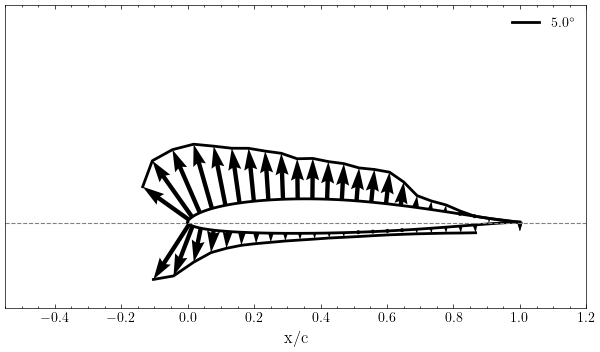

In [14]:
sd6060 = pd.read_table("SD6060-104-88_180.dat", sep='\\s+', skiprows=[0], names=['x', 'y'], index_col=False)

x, y = sd6060.x, sd6060.y

te_index = np.argmin(x)

x_upper = np.array(list(reversed(x[:te_index + 1])))
y_upper = np.array(list(reversed(y[:te_index + 1])))

x_lower = x[te_index:]
y_lower = y[te_index:]

cs_upper = CubicSpline(x_upper, y_upper)
cs_lower = CubicSpline(x_lower, y_lower)

def normal_vector(x, y):
    if y < 0:
        dy_dx = cs_lower(x, 1)
    else:
        dy_dx = cs_upper(x, 1)
    normal = np.array([-dy_dx, 1])
    normal = normal / np.linalg.norm(normal) 
    return normal


fig(0.8)
base = plt.gca().transData
rot = transforms.Affine2D().rotate_deg(-10)
tr = base # + rot

plt.plot(x_upper, cs_upper(x_upper), linewidth=2, color="black", transform=tr)
plt.plot(x_lower, cs_lower(x_lower), linewidth=2, color="black", transform=tr)

# plt.scatter(p_taps.x, p_taps.y, color="blue", marker="x", label="Pressure taps")

for i, (alpha, (x_lower, C_p_lower, x_upper, C_p_upper)) in enumerate(alpha_to_x_cp.items()):
    x_lower, C_p_lower = zip(*sorted(zip(x_lower, C_p_lower)))
    x_upper, C_p_upper = zip(*sorted(zip(x_upper, C_p_upper)))
    
    linestyle = linestyles[list(alpha_to_x_cp.keys()).index(alpha)]

    delta = min(np.min(np.array(C_p_lower) * q_inf_2d[i]), np.min(np.array(C_p_upper) * q_inf_2d[i]))

    forces_lower = np.array([normal_vector(x, -1) * cp * q_inf_2d[i] * 0.001 for x, cp in zip(x_lower, C_p_lower)])
    forces_upper = np.array([normal_vector(x, 1) * cp * q_inf_2d[i] * 0.001 for x, cp in zip(x_upper, C_p_upper)])

    curve_color = colors[i]

    arrow_tips = []
    for j, (x, y, f, cp) in enumerate((list(zip(x_lower, cs_lower(x_lower), forces_lower, C_p_lower)) + list(reversed(list(zip(x_upper, cs_upper(x_upper), forces_upper, C_p_upper)))))):
        if j < 2:
            continue

        if (cp > 0 and y > 0) or (cp < 0 and y < 0):
            arrow_tips.append((x, y))  # Tip is at (x, y)
            plt.quiver(x, y, -f[0], -f[1], angles='xy', scale_units='xy', scale=1, color=curve_color, transform=tr)
        else:
            arrow_tips.append((x - f[0], y -f[1]))  # Tip is at (x + f[0], y + f[1])
            plt.quiver(x, y, -f[0], -f[1], angles='xy', scale_units='xy', scale=1, color=curve_color, transform=tr)

    arrow_tips = np.array(arrow_tips)

    #arrow_tips = arrow_tips[np.argsort(arrow_tips[:, 0])]  # Sort by x-coordinate
    #plt.scatter(arrow_tips[-1, 0], arrow_tips[-1, 1], color='black', transform=tr)

    plt.plot(arrow_tips[:22, 0], arrow_tips[:22, 1], color=curve_color, lw=2, transform=tr, label=f'{alpha}$^\circ$')
    plt.plot(arrow_tips[23:, 0], arrow_tips[23:, 1], color=curve_color, lw=2, transform=tr)

    #tck, _ = splprep([arrow_tips[:24, 0], arrow_tips[:24, 1]], per=True, s=0)
    #u = np.linspace(0, 0.55 if i == 0 else 0.4, 300)
    #fitted_x, fitted_y = splev(u, tck)
    #plt.plot(fitted_x, fitted_y, label=f'{alpha}$^\circ$', color=curve_color, lw=2)

    #tck, _ = splprep([arrow_tips[23:, 0], arrow_tips[23:, 1]], per=True, s=0)
    #u = np.linspace(0, 0.68  if i == 0 else 0.51, 300)
    #fitted_x, fitted_y = splev(u, tck)
    #plt.plot(fitted_x, fitted_y, color=curve_color, lw=2)


plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Chord line
plt.gca().set_aspect('equal', adjustable='datalim')
legend()

plt.yticks([])

plt.xlabel("x/c", fontsize=12)

plt.ylim((-0.6, 1))
plt.xlim((-0.55, 1.2))

plt.tight_layout()

plt.savefig("p_dist.pgf", format="pgf")

plt.show()

/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/3110662751.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  C_n = (np.trapz(C_p_lower, x_lower) - np.trapz(C_p_upper, x_upper))
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/3110662751.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  moment_lower = np.trapz(C_p_lower * x_lower, x_lower)
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/3110662751.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  moment_upper = np.trapz(C_p_upper * x_upper, x_upper)
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/3110662751.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of 

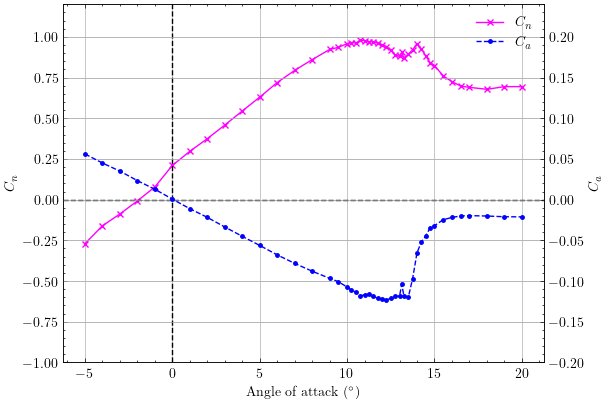

In [91]:
for i, row in raw_2d.iterrows():
    for p_tap in p_taps_names:
        p = row[p_tap]
        C_p = p / q_inf_2d[i]

        x = p_taps[p_taps.idx == p_tap].x.values[0]
        y = p_taps[p_taps.idx == p_tap].y.values[0]

        if y <= 0:
            alpha_to_x_cp.setdefault(row.Alpha, ([], [], [], []))[0].append(x / 100)
            alpha_to_x_cp.setdefault(row.Alpha, ([], [], [], []))[1].append(C_p)
        else:
            alpha_to_x_cp.setdefault(row.Alpha, ([], [], [], []))[2].append(x / 100)
            alpha_to_x_cp.setdefault(row.Alpha, ([], [], [], []))[3].append(C_p)

alphas = []
C_ns = []
C_ms = []
C_as = []
for i, (alpha, (x_lower, C_p_lower, x_upper, C_p_upper)) in enumerate(alpha_to_x_cp.items()):
    x_lower, C_p_lower = zip(*sorted(zip(x_lower, C_p_lower)))
    x_upper, C_p_upper = zip(*sorted(zip(x_upper, C_p_upper)))

    x_lower, C_p_lower = np.array(x_lower), np.array(C_p_lower)
    x_upper, C_p_upper = np.array(x_upper), np.array(C_p_upper)

    # C_n
    C_n = (np.trapz(C_p_lower, x_lower) - np.trapz(C_p_upper, x_upper))

    # C_m
    moment_lower = np.trapz(C_p_lower * x_lower, x_lower)
    moment_upper = np.trapz(C_p_upper * x_upper, x_upper)
    C_m = moment_upper - moment_lower

    # Local angles
    theta_upper = np.arctan(cs_upper.derivative()(x_upper))
    theta_lower = np.arctan(cs_lower.derivative()(x_lower))

    # Tangential contributions to axial force
    C_a_upper = np.trapz(C_p_upper * np.sin(theta_upper), x_upper)
    C_a_lower = np.trapz(C_p_lower * np.sin(theta_lower), x_lower)

    # C_a
    C_a = C_a_upper + C_a_lower

    alphas.append(alpha)
    C_ns.append(C_n)
    C_ms.append(C_m)
    C_as.append(C_a)


alphas, C_ns, C_ms, C_as = zip(*sorted(zip(alphas, C_ns, C_ms, C_as)))

alphas = np.array(alphas)
C_ns = np.array(C_ns)
C_ms = np.array(C_ms)
C_as = np.array(C_as)

C_d = C_ns * np.sin(np.radians(alphas)) + C_as * np.cos(np.radians(alphas))
C_l = C_ns * np.cos(np.radians(alphas)) - C_as * np.sin(np.radians(alphas))

fig(1)
ax1 = plt.gca()
ax1.plot(alphas, C_ns, marker='x', linestyle='-', color='magenta', markersize=5, label='$C_n$')
ax1.grid()
ax1.axvline(0, color="black", linestyle="--")
ax1.axhline(0, color="black", linestyle="--")
ax1.set_ylabel("$C_n$")
ax1.set_ylim(-1, 1.2)

ax2 = ax1.twinx()
ax2.plot(alphas, C_as, marker='.', linestyle='--', color='blue', markersize=5, label='$C_a$')
ax2.set_ylabel("$C_a$")
ax2.grid()
ax2.set_ylim(-1/5, 1.2/5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend(lines1 + lines2, labels1 + labels2, loc="best")

ax1.set_xlabel("Angle of attack ($^\\circ$)")

plt.savefig("C_n C_a.pgf", format="pgf")

<>:23: SyntaxWarning: invalid escape sequence '\q'
<>:23: SyntaxWarning: invalid escape sequence '\q'
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/4079306589.py:23: SyntaxWarning: invalid escape sequence '\q'
  ax2.set_ylabel("$C_m\quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad C_d$")


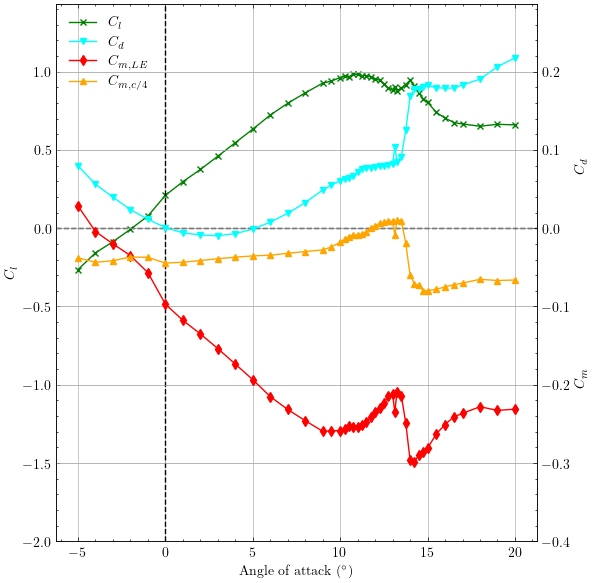

In [95]:
fig(1.5)

ax1 = plt.gca()
ax1.plot(alphas, C_l, marker='x', linestyle='-', color='green', markersize=5, label='$C_l$')
ax1.set_xlabel("Angle of attack ($^\\circ$)")
ax1.set_ylabel("$C_l$")

ax1.grid(True)
ax1.axvline(0, color="black", linestyle="--")
ax1.axhline(0, color="black", linestyle="--")

ax2 = ax1.twinx()

C_ms_c4 = C_ms + C_l / 4

markers = ['x', 'o', 's', '^', 'v', '<', '>', 'd', 'p', 'P', '*', 'h', 'H', '+', 'X', '|', '_']

ax2.plot(alphas, C_d, marker='v', linestyle='-', color='cyan', markersize=5, label='$C_d$')

ax2.plot(alphas, C_ms, marker='d', linestyle='-', color='red', markersize=5, label='$C_{m,LE}$')
ax2.plot(alphas, C_ms_c4, marker='^', linestyle='-', color='orange', markersize=5, label='$C_{m,c/4}$')

ax2.set_ylabel("$C_m\quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad C_d$")

ax1.set_ylim(-2, 1.43)
ax2.set_ylim(-2/5, 1.43/5)
ax2.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.savefig("Cl Cm Cd.pgf", format="pgf")

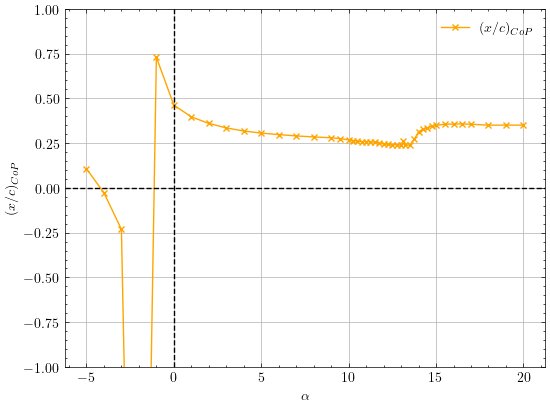

In [17]:
x_c_cop = -C_ms / C_l
fig()
plt.plot(alphas, x_c_cop, marker='x', linestyle='-', color='orange', markersize=5, label='$(x/c)_{CoP}$')
plt.grid()
plt.xlabel("$\\alpha$")
plt.ylabel("$(x/c)_{CoP}$")
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")
plt.ylim(-1, 1)
legend()
plt.savefig("alpha xcp.pgf", format="pgf")
plt.show()

In [18]:
rake_p_t = pd.read_excel("SLT practical coordinates.xlsx", sheet_name="Sheet1", names=['', '', '', '', 'p_t', 'y[mm]'], index_col=False, header=1)
rake_p_t = rake_p_t.drop(columns=['', '.1', '.2', '.3']).dropna()
rake_p_t.head()

/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/1085501755.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  rake_p_t = pd.read_excel("SLT practical coordinates.xlsx", sheet_name="Sheet1", names=['', '', '', '', 'p_t', 'y[mm]'], index_col=False, header=1)


,p_t,y[mm]
0,P050,0.0
1,P051,12.0
2,P052,21.0
3,P053,27.0
4,P054,33.0


In [19]:
rake_p_s = pd.read_excel("SLT practical coordinates.xlsx", sheet_name="Sheet1", names=['', '', '', '', '', '', '', 'p_t', 'y[mm]'], index_col=False, header=1)
rake_p_s = rake_p_s.drop(columns=['', '.1', '.2', '.3', '.4', '.5', '.6']).dropna()
rake_p_s.head()

/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/3028637807.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  rake_p_s = pd.read_excel("SLT practical coordinates.xlsx", sheet_name="Sheet1", names=['', '', '', '', '', '', '', 'p_t', 'y[mm]'], index_col=False, header=1)


,p_t,y[mm]
0,P098,43.5
1,P099,55.5
2,P100,67.5
3,P101,79.5
4,P102,91.5


In [20]:
from scipy.interpolate import interp1d

/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/2698960167.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  D_m = np.trapz(momentum_deficit, y_p_t)
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/2698960167.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  D_p = np.trapz(pressure_deficit, y_p_t)
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/2698960167.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  l = axes[0].legend(fancybox=False, edgecolor="black")
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/2698960167.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose l

[ 2.78208834  2.75230479  1.93730792  2.86149957  3.05995405  3.13930637
  1.94725749  1.67852742  2.9235279   2.94337479  3.34256972  3.45159217
  3.37230629  3.52095346  3.47388828  2.94337479  3.95911603  4.26082429
  3.99622461  6.30437893 17.3989162  32.55468979 42.40827876 42.45330818
 31.85396007 14.43138531  7.77375394  4.334977    4.03332947  4.19654651
  6.6778185   4.20396375  4.69810891  7.63909089  4.85362668  4.01848798
  4.75489291  4.90791888  4.75365857  4.00735646  4.35351284  1.67977198
  2.36490381  5.14720169  3.91210647  2.3152082   1.95720681]
[ 4.02724132  3.28452684  2.91756629  3.82933174  3.98766801  4.11626553
  2.76869443  2.52044152  3.8553135   3.8008734   4.13851818  4.52895344
  4.1978519   4.25223262  4.4511471   3.55826884  4.52524876  5.21366516
  6.48092091 12.9793395  25.87779642 35.6491199  34.27623811 23.91444648
 14.47193371  5.55368411  4.96707251  4.2386382   4.48819983  4.78695285
  7.26482745  4.61291609  4.81533385  7.50492179  4.68698456  

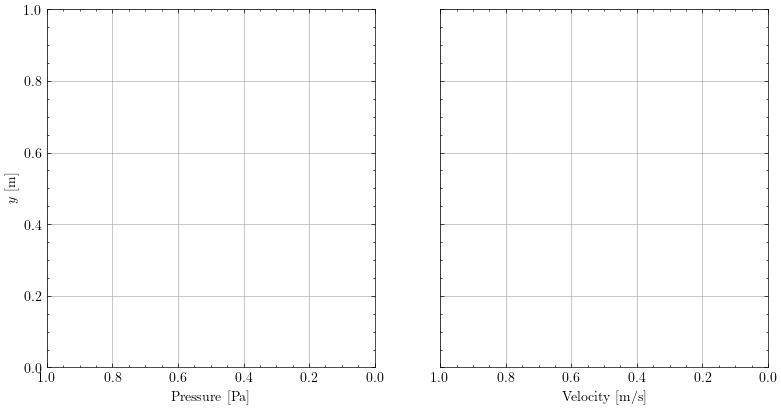

In [21]:
alpha_to_p_t = {}
alpha_to_p_s = {}

alpha_to_p097 = {}

for i, row in raw_2d.iterrows():
    alpha = row.Alpha
    for (i, (p_t_tap, y)) in rake_p_t.iterrows():
        alpha_to_p_t.setdefault(alpha, []).append((row[p_t_tap], y / 100))

    for (i, (p_s_tap, y)) in rake_p_s.iterrows():
        alpha_to_p_s.setdefault(alpha, []).append((row[p_s_tap], y / 100))

    alpha_to_p097.setdefault(alpha, []).append(row['P097'])

markers = list(['x', 'o', 's', '^', 'd', 'p', 'P', '*', 'h', 'H', '+', 'X', '|', '_'])
linestyles = list(reversed(["-", "--", "-.", ":", "-", '--', '-']))
colors = list(reversed(['gray', 'black', 'lightgreen', 'green', 'darkgreen', 'red', 'orange', 'darkred', 'darkblue', 'blue', 'cyan']))

for i in range(2):
    markers += markers
    linestyles += linestyles
    colors += colors

_, axes = plt.subplots(1, 2, figsize=(width * 1.5, height), sharey=True)

alphas = []
Ds = []

# :60:21
for i, (alpha, p_t) in enumerate(list(alpha_to_p_t.items())[::]):
    
    p_t = np.array(p_t)
    y_p_t = p_t[:, 1]
    p_t = p_t[:, 0]

    p_s = np.array(alpha_to_p_s[alpha])
    y_p_s = p_s[1:, 1]
    p_s = p_s[1:, 0]
 
    p_s_interp = interp1d(y_p_s, p_s, kind='linear', fill_value="extrapolate")
    p_s_extrapolated = p_s_interp(y_p_t)
    p_s_extrapolated[y_p_t < y_p_s.min()] = p_s[0]
    p_s_extrapolated[y_p_t > y_p_s.max()] = p_s[-1]

    u = velocity_from_bernoulli(p_t, p_s_extrapolated)

    momentum_deficit = rho * (u_inf_2d[i] - u) * u
    print(momentum_deficit)

    pressure_deficit = p_s_extrapolated # (np.array(alpha_to_p097[alpha]) - q_inf_2d[i] - p_s_extrapolated)
    D_m = np.trapz(momentum_deficit, y_p_t) 
    D_p = np.trapz(pressure_deficit, y_p_t)

    alphas.append(alpha)
    Ds.append(D_m ) #+ D_p)
    #print(D_m, D_p)
    #axes[0].plot(p_t, y_p_t, label=f"$\Delta p_t$ {alpha}$^\\circ$", marker=markers.pop(0), linestyle=linestyles.pop(0), markersize=3, color=colors.pop(0))
    #axes[0].plot(p_s, y_p_s, label=f"$\Delta p_s$ ", marker=markers.pop(0), linestyle=linestyles.pop(0), markersize=3, color=colors.pop(0))

    #axes[1].plot(u, y_p_t, label=f"$U$ {alpha}$^\\circ$", marker='.', linestyle='-', color=colors.pop(0))

axes[0].invert_xaxis()
axes[0].set_ylabel("$y$ [m]")
axes[0].set_xlabel("Pressure [Pa]")  
axes[0].grid()  

axes[1].invert_xaxis()
axes[1].set_xlabel("Velocity [m/s]")  
axes[1].grid()  

l = axes[0].legend(fancybox=False, edgecolor="black")
l.get_frame().set_linewidth(0.5)
l = axes[1].legend(fancybox=False, edgecolor="black")
l.get_frame().set_linewidth(0.5)

plt.savefig("p_t p_s U.pgf", format="pgf")
plt.show()

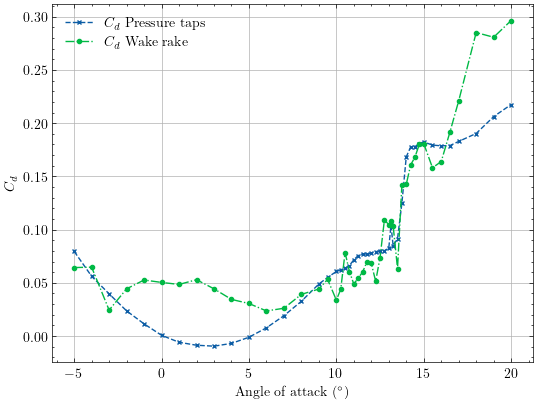

In [22]:
C_d_rake = np.array(Ds) / (0.5 * rho * u_inf_2d ** 2)

fig()
plt.plot(alphas, C_d, label="$C_d$ Pressure taps", marker='x', linestyle="--", markersize=3)
plt.plot(alphas, C_d_rake, label="$C_d$ Wake rake", marker='o', linestyle='-.', markersize=3)
plt.xlabel("Angle of attack ($^\\circ$)")
plt.ylabel("$C_d$")
legend()
plt.grid()
plt.savefig("C_d comparison.pgf", format="pgf")

In [23]:
#
# Wind-tunnel corrections
# 
wide = 0.9
sigma = (np.pi **2 / 48) * (0.160/wide)**2
tau = (1/4) * (0.160/wide)

speed_of_sound = np.sqrt(1.4 * 287 * (273.15 + raw_2d['T'].mean()))

M = u_inf_2d / speed_of_sound

corr_1 = []
corr_2 = (1 + 0.4 * M**2)/(1-M**2) * tau * C_d_rake 

rho_corr = []
cd_corr_an = []
cl_corr_an = []
cmc4_corr_an = []
for i, (alpha, (x_lower, C_p_lower, x_upper, C_p_upper)) in enumerate(alpha_to_x_cp.items()):
    x_lower, C_p_lower = zip(*sorted(zip(x_lower, C_p_lower)))
    x_upper, C_p_upper = zip(*sorted(zip(x_upper, C_p_upper)))

    x_lower, C_p_lower = np.array(x_lower), np.array(C_p_lower)
    x_upper, C_p_upper = np.array(x_upper), np.array(C_p_upper)

    Lambda_u = 16 / np.pi * np.trapezoid(cs_upper(x_upper) * np.sqrt((1 - C_p_upper) * (1 + (cs_lower.derivative()(x_upper))**2)), x_upper)
    # Lambda_l = 16 / np.pi * np.trapezoid(cs_lower(x_lower) * np.sqrt((1 - C_p_lower) * (1 + (cs_upper.derivative()(x_lower))**2)), x_lower)
    corr_1.append(Lambda_u * sigma / (1-M[i]**2)**(3/2))
    
    rho_corr.append(rho * (1 - M[i]**2 / (1-M[i]**2)**(3/2) * Lambda_u * sigma - M[i]**2 * (1 + 0.4 * M[i]**2) / (1 - M[i]**2) * tau * C_d_rake[i]))

    cd_corr_an.append(C_d_rake[i] * (1 - (3 - 0.6 * M[i]**2)/(1-M[i]**2)**(3/2) * Lambda_u * sigma - (2-M[i]**2) * (1+ 0.4 * M[i]**2)/(1-M[i]**2) * tau * C_d_rake[i]))
    cl_corr_an.append(C_l[i] * (1 - sigma/(1- M[i]**2) - (2 - M[i]**2)/((1-M[i]**2)**(3/2)) * Lambda_u * sigma - (2-M[i]**2) * (1+ 0.4 * M[i]**2)/(1-M[i]**2) * tau * C_d_rake[i]))
    cmc4_corr_an.append(C_ms_c4[i] * (1 - (2 - M[i]**2)/((1-M[i]**2)**(3/2)) * Lambda_u * sigma - (2-M[i]**2) * (1+ 0.4 * M[i]**2)/(1-M[i]**2) * tau * C_d_rake[i]) + C_l[i] * sigma / (4 * (1 - M[i]**2)))

u_inf_2d_corr = u_inf_2d + u_inf_2d * np.array(corr_1 + corr_2)
q_inf_2d_corr = 0.5 * rho * u_inf_2d_corr ** 2
print(np.array(cmc4_corr_an).shape)

(45,)


<>:27: SyntaxWarning: invalid escape sequence '\q'
<>:27: SyntaxWarning: invalid escape sequence '\q'
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/2390594391.py:27: SyntaxWarning: invalid escape sequence '\q'
  ax2.set_ylabel("$C_m\quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad C_d$")


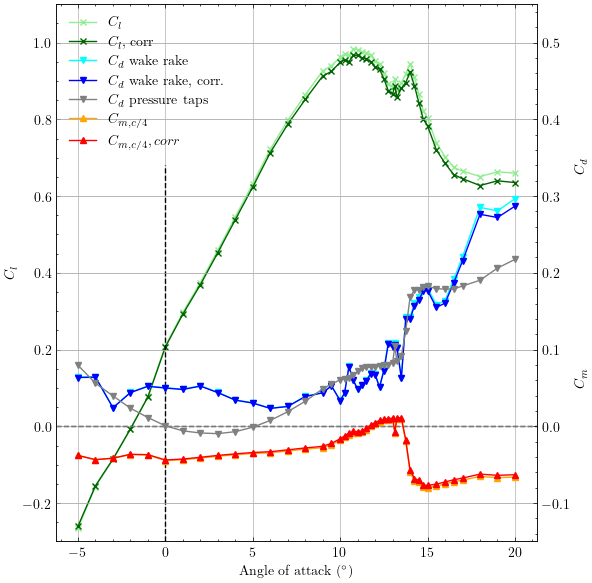

In [ ]:
fig(1.5)

ax1 = plt.gca()
ax1.plot(alphas, C_l, marker='x', linestyle='-', color='lightgreen', markersize=5, label='$C_l$')
ax1.plot(alphas, cl_corr_an, marker='x', linestyle='-', color='darkgreen', markersize=5, label='$C_l$, corr.')
ax1.set_xlabel("Angle of attack ($^\\circ$)")
ax1.set_ylabel("$C_l$")

ax1.grid(True)
ax1.axvline(0, ymax=0.7, color="black", linestyle="--")
ax1.axhline(0, color="black", linestyle="--")

ax2 = ax1.twinx()

C_ms_c4 = C_ms + C_l / 4

markers = ['x', 'o', 's', '^', 'v', '<', '>', 'd', 'p', 'P', '*', 'h', 'H', '+', 'X', '|', '_']

ax2.plot(alphas, C_d_rake, marker='v', linestyle='-', color='cyan', markersize=5, label='$C_d$ wake rake')
ax2.plot(alphas, cd_corr_an, marker='v', linestyle='-', color='blue', markersize=5, label='$C_d$ wake rake, corr.')

ax2.plot(alphas, C_d, marker='v', linestyle='-', color='gray', markersize=5, label='$C_d$ pressure taps')

ax2.plot(alphas, C_ms_c4, marker='^', linestyle='-', color='orange', markersize=5, label='$C_{m,c/4}$')
ax2.plot(alphas, cmc4_corr_an, marker='^', linestyle='-', color='red', markersize=5, label='$C_{m,c/4}$, corr.')

ax2.set_ylabel("$C_m\quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad C_d$")

ax1.set_ylim(-0.3, 1.1)
ax2.set_ylim(-0.3/2, 1.1/2)
ax2.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.savefig("Cl Cm Cd corr.pgf", format="pgf")

In [25]:
Ds_corr = []

for i, (alpha, p_t) in enumerate(list(alpha_to_p_t.items())[::]):
    p_t = np.array(p_t)
    y_p_t = p_t[:, 1]
    p_t = p_t[:, 0]

    p_s = np.array(alpha_to_p_s[alpha])
    y_p_s = p_s[1:, 1]
    p_s = p_s[1:, 0]
 
    p_s_interp = interp1d(y_p_s, p_s, kind='linear', fill_value="extrapolate")
    p_s_extrapolated = p_s_interp(y_p_t)
    p_s_extrapolated[y_p_t < y_p_s.min()] = p_s[0]
    p_s_extrapolated[y_p_t > y_p_s.max()] = p_s[-1]

    u = velocity_from_bernoulli(p_t, p_s_extrapolated)

    momentum_deficit = rho_corr[i] * (u_inf_2d_corr[i] - u) * u
    pressure_deficit = (np.array(alpha_to_p097[alpha]) - q_inf_2d_corr[i] - p_s_extrapolated)
    D_m = np.trapezoid(momentum_deficit, y_p_t) 
    D_p = np.trapezoid(pressure_deficit, y_p_t)

    Ds_corr.append(D_m + D_p)
    #axes[0].plot(p_t, y_p_t, label=f"$\Delta p_t$ {alpha}$^\\circ$", marker=markers.pop(0), linestyle=linestyles.pop(0), markersize=3, color=colors.pop(0))
    #axes[0].plot(p_s, y_p_s, label=f"$\Delta p_s$ ", marker=markers.pop(0), linestyle=linestyles.pop(0), markersize=3, color=colors.pop(0))

    #axes[1].plot(u, y_p_t, label=f"$U$ {alpha}$^\\circ$", marker='.', linestyle='-', color=colors.pop(0))


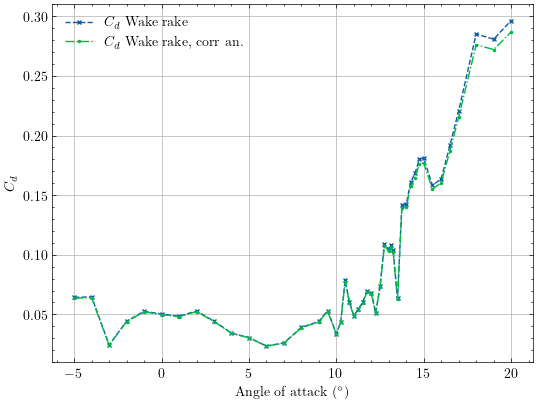

In [26]:
C_d_rake_corr = np.array(Ds_corr) / (0.5 * rho * u_inf_2d_corr ** 2 * 0.160)

fig()
plt.plot(alphas, C_d_rake, label="$C_d$ Wake rake", marker='x', linestyle="--", markersize=3)
# plt.plot(alphas, C_d_rake_corr, label="$C_d$ Wake rake, corr", marker='o', linestyle='-.', markersize=3)
plt.plot(alphas, cd_corr_an, label="$C_d$ Wake rake, corr an.", marker='.', linestyle='-.', markersize=3)
plt.xlabel("Angle of attack ($^\\circ$)")
plt.ylabel("$C_d$")
legend()
plt.grid()
plt.savefig("C_d comparison corr.pgf", format="pgf")

In [27]:
S = (0.13 / 2)
S

0.065

In [28]:
A = 0.4169/0.160
A

2.605625

In [29]:
C_L = np.array(df_3d.Fy.values / (np.array(q_inf_3d) * S))
C_D = np.array(df_3d.Fx.values / (np.array(q_inf_3d) * S))
df_3d.Alpha, C_L, C_D = zip(*sorted(zip(df_3d.Alpha.values, C_L, C_D)))

print(C_L, C_D)

vlm2 = pd.read_csv("T1-17_9 m_s-VLM2.csv", skiprows=6)
vlm2.columns = vlm2.columns.str.strip()

vlm1 = pd.read_csv("T1-17_9 m_s-VLM1.csv", skiprows=6)
vlm1.columns = vlm1.columns.str.strip()

llt = pd.read_csv("T1-17_9 m_s-LLT.csv", skiprows=6)
llt.columns = vlm2.columns.str.strip()

(np.float64(-0.23954559237953996), np.float64(-0.14819057722130297), np.float64(-0.0786101541859432), np.float64(-0.021155260790137267), np.float64(0.05012070076110246), np.float64(0.11650827902361624), np.float64(0.11800346041521965), np.float64(0.22578448970306436), np.float64(0.29472492666719663), np.float64(0.3633542840754195), np.float64(0.4292946416362566), np.float64(0.515371471174458), np.float64(0.5835942923179124), np.float64(0.6301960119644945), np.float64(0.6608120020974207), np.float64(0.7105542053713041), np.float64(0.7381366770300892), np.float64(0.7738555172854338), np.float64(0.8049850738537295), np.float64(0.8323315769577089), np.float64(0.8708800299827584), np.float64(0.8869563771295969), np.float64(0.8943948738330326), np.float64(0.9017364584028145), np.float64(0.9168182768656765), np.float64(0.9256341661239883), np.float64(0.9292662639553741), np.float64(0.9403574214391287), np.float64(0.9526653427690004), np.float64(0.9489541245788541), np.float64(0.96369178159483

In [32]:
from scipy.stats import linregress

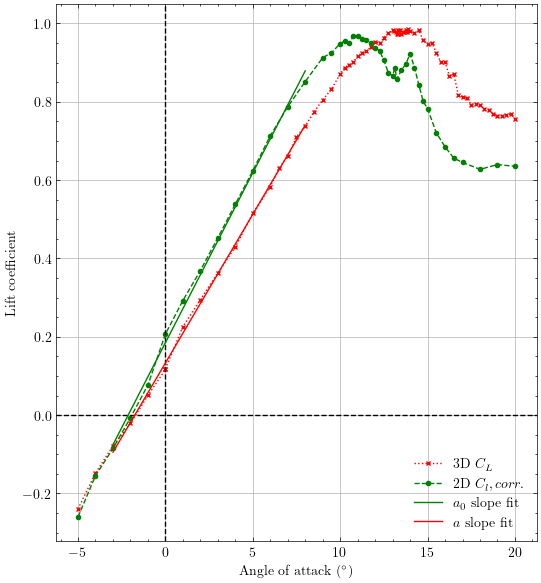

In [39]:
fig(1.5)

ax1 = plt.gca()
ax1.plot(df_3d.Alpha, C_L, label="3D $C_L$", marker='x', linestyle=':', color="red", markersize=3)
ax1.plot(alphas, cl_corr_an, label='2D $C_l, corr.$', marker='o', linestyle='--', color="green", markersize=3)
ax1.set_xlabel("Angle of attack ($^\\circ$)")
ax1.set_ylabel("Lift coefficient")

ax1.grid(True)
ax1.axvline(0, color="black", linestyle="--")
ax1.axhline(0, color="black", linestyle="--")

alphas = np.array(alphas)

alpha_range = (-3, 8)
mask_3d = (df_3d.Alpha.values >= alpha_range[0]) & (df_3d.Alpha.values <= alpha_range[1])
mask_2d = (alphas >= alpha_range[0]) & (alphas <= alpha_range[1])

alphas_3d = df_3d.Alpha.values[mask_3d]
cl_3d = np.array(C_L)[mask_3d]

alpha_2d_filtered = alphas[mask_2d]
cl_2d_filtered = np.array(cl_corr_an)[mask_2d]

slope_3d, intercept_3d, _, _, _ = linregress(alphas_3d, cl_3d)
slope_2d, intercept_2d, _, _, _ = linregress(alpha_2d_filtered, cl_2d_filtered)

slope_2d, slope_3d = slope_2d , slope_3d 
slope_2d, slope_3d

# plot slope_2d and slope_3d between -3 and 8
x = np.linspace(-3, 8, 100)
y_2d = slope_2d * x + intercept_2d
y_3d = slope_3d * x + intercept_3d
plt.plot(x, y_2d, label="$a_0$ slope fit", color="green")
plt.plot(x, y_3d, label="$a$ slope fit", color="red")

C_ms_c4 = C_ms + C_l / 4

markers = ['x', 'o', 's', '^', 'v', '<', '>', 'd', 'p', 'P', '*', 'h', 'H', '+', 'X', '|', '_']
legend()

plt.savefig("2D 3D comp C_L.pgf", format="pgf")

In [40]:
slope_2d, slope_3d

(np.float64(0.0867637024047645), np.float64(0.07592478991983909))

In [34]:
slope_2d, slope_3d = slope_2d * 57.3, slope_3d * 57.3
slope_2d, slope_3d

(np.float64(4.971560147793006), np.float64(4.350490462406779))

In [35]:
tau = (slope_2d/slope_3d - 1) / (slope_2d / (np.pi * A)) - 1
tau

np.float64(-0.764944077639824)

In [36]:
slope_2d / (1 + slope_2d /(np.pi * A) * (1 + tau)), slope_3d

(np.float64(4.350490462406779), np.float64(4.350490462406779))

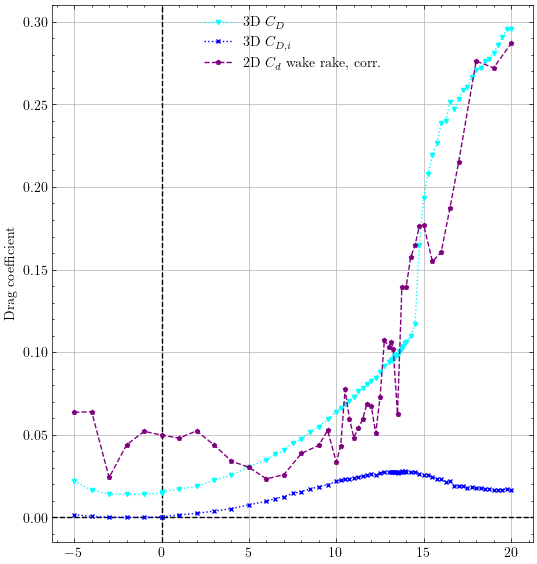

In [47]:
fig(1.5)

C_d_i = np.array(C_L)**2 /(np.pi * A) * (1 + tau)

ax1 = plt.gca()

ax1.grid(True)
ax1.axvline(0, color="black", linestyle="--")
ax1.axhline(0, color="black", linestyle="--")

C_ms_c4 = C_ms + C_l / 4

markers = ['x', 'o', 's', '^', 'v', '<', '>', 'd', 'p', 'P', '*', 'h', 'H', '+', 'X', '|', '_']

ax1.plot(df_3d.Alpha, C_D, marker='v', linestyle=':', markersize=3, color="cyan", label='3D $C_D$')
ax1.plot(df_3d.Alpha, C_d_i, marker='x', linestyle=':', markersize=3, color="blue", label='3D $C_{D,i}$')
ax1.plot(alphas, cd_corr_an, marker='p', linestyle='--', markersize=3, color="purple", label='2D $C_d$ wake rake, corr.')

ax1.set_ylabel("Drag coefficient")

legend()
plt.savefig("2D 3D comp C_D.pgf", format="pgf")

In [54]:
#read T1_Re0.180_M0.00_N9.0.csv skip 6 rows
df_2d_xfoil = pd.read_csv("T1_Re0.180_M0.00_N9.0.csv", skiprows=9, dtype=float)
df_2d_xfoil.columns = df_2d_xfoil.columns.str.strip()
df_2d_xfoil.head()

,alpha,CL,CD,CDp,Cm,Top Xtr,Bot Xtr,Cpmin,Chinge,XCp,0,0.1,0.2
0,-5.0,-0.3843,0.02102,0.01340,-0.0371,0.9728,0.0314,-3.3413,0.0,0.0,0.0,0.1481,NaN
1,-4.5,-0.3090,0.01792,0.01005,-0.0407,0.9632,0.0357,-2.9918,0.0,0.0,0.0,0.1126,NaN
2,-4.0,-0.2380,0.01538,0.00760,-0.0441,0.9518,0.0573,-2.6434,0.0,0.0,0.0,0.0587,NaN
3,-3.5,-0.1813,0.01251,0.00609,-0.0457,0.9375,0.3145,-2.2974,0.0,0.0,0.0,-0.0087,NaN
4,-3.0,-0.1379,0.01090,0.00599,-0.0426,0.9216,0.6969,-1.8600,0.0,0.0,0.0,-0.0660,NaN


<>:25: SyntaxWarning: invalid escape sequence '\q'
<>:25: SyntaxWarning: invalid escape sequence '\q'
/var/folders/2n/wl3swsls16j5t171fclgl_mc0000gn/T/ipykernel_35602/3419948553.py:25: SyntaxWarning: invalid escape sequence '\q'
  ax2.set_ylabel("$C_m\quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad C_d$")


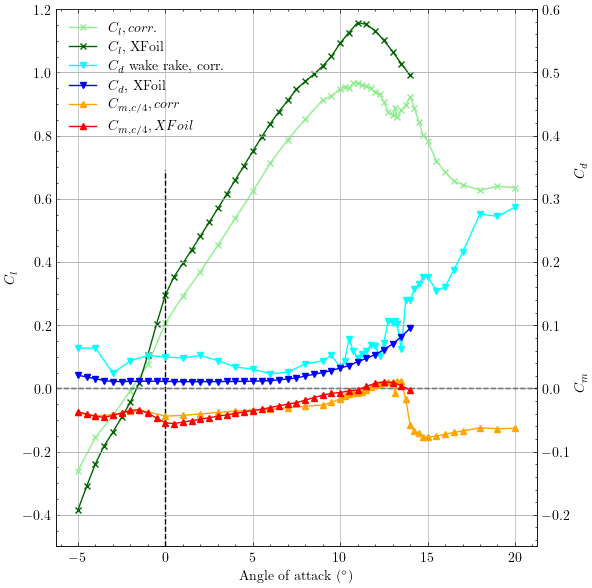

In [100]:
fig(1.5)

ax1 = plt.gca()
ax1.plot(alphas, cl_corr_an, marker='x', linestyle='-', color='lightgreen', markersize=5, label='$C_l, corr.$')
ax1.plot(df_2d_xfoil.alpha, df_2d_xfoil.CL, marker='x', linestyle='-', color='darkgreen', markersize=5, label='$C_l$, XFoil')
ax1.set_xlabel("Angle of attack ($^\\circ$)")
ax1.set_ylabel("$C_l$")

ax1.grid(True)
ax1.axvline(0, ymax=0.7, color="black", linestyle="--")
ax1.axhline(0, color="black", linestyle="--")

ax2 = ax1.twinx()

C_ms_c4 = C_ms + C_l / 4

markers = ['x', 'o', 's', '^', 'v', '<', '>', 'd', 'p', 'P', '*', 'h', 'H', '+', 'X', '|', '_']

ax2.plot(alphas, cd_corr_an, marker='v', linestyle='-', color='cyan', markersize=5, label='$C_d$ wake rake, corr.')
ax2.plot(df_2d_xfoil.alpha, df_2d_xfoil.CD, marker='v', linestyle='-', color='blue', markersize=5, label='$C_d$, XFoil')

ax2.plot(alphas, cmc4_corr_an, marker='^', linestyle='-', color='orange', markersize=5, label='$C_{m,c/4}, corr$')
ax2.plot(df_2d_xfoil.alpha, df_2d_xfoil.Cm, marker='^', linestyle='-', color='red', markersize=5, label='$C_{m,c/4}, XFoil$')

ax2.set_ylabel("$C_m\quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad C_d$")

ax1.set_ylim(-0.5, 1.2)
ax2.set_ylim(-0.5/2, 1.2/2)
ax2.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.savefig("Cl Cm Cd XFoil.pgf", format="pgf")

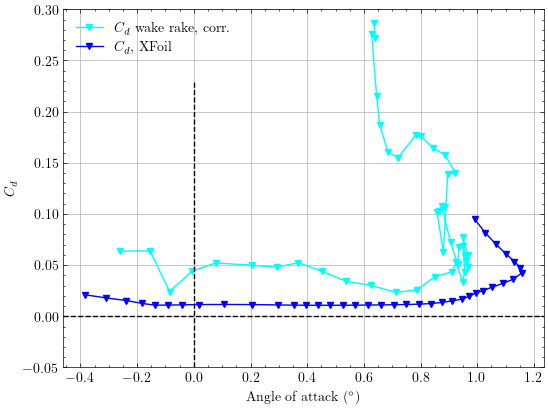

In [104]:
fig()
plt.xlabel("$C_l")
plt.ylabel("$C_d$")

plt.plot(cl_corr_an, cd_corr_an, marker='v', linestyle='-', color='cyan', markersize=5, label='$C_d$ wake rake, corr.')
plt.plot(df_2d_xfoil.CL, df_2d_xfoil.CD, marker='v', linestyle='-', color='blue', markersize=5, label='$C_d$, XFoil')

plt.axvline(0, ymax=0.8, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Angle of attack ($^\\circ$)")
plt.ylabel("$C_d$")
legend()
plt.ylim(-0.05, 0.3)
plt.grid()
plt.savefig("C_d comparison XFoil.pgf", format="pgf")

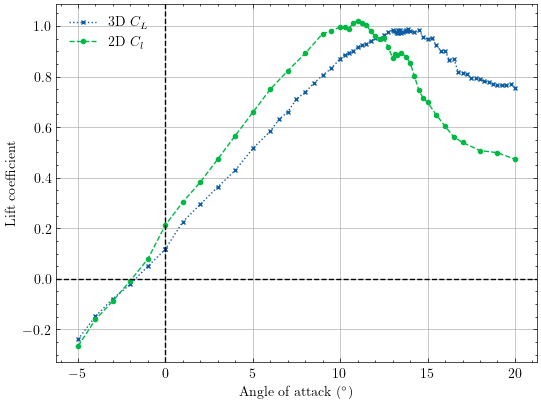

In [ ]:
fig()

plt.grid()
legend()
plt.xlabel("Angle of attack ($^\\circ$)")
plt.ylabel("Lift coefficient")
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")
plt.savefig("2D 3D C_L.pgf", format="pgf")
plt.show()

In [ ]:
fig(1.5)

ax1 = plt.gca()
ax1.plot(alphas, C_l, marker='x', linestyle='-', color='lightgreen', markersize=5, label='$C_l$')
ax1.plot(df_2d_xfoil.alpha, df_2d_xfoil.CL, marker='x', linestyle='-', color='darkgreen', markersize=5, label='$C_l$, XFoil')
ax1.set_xlabel("Angle of attack ($^\\circ$)")
ax1.set_ylabel("$C_l$")

ax1.grid(True)
ax1.axvline(0, ymax=0.7, color="black", linestyle="--")
ax1.axhline(0, color="black", linestyle="--")

ax2 = ax1.twinx()

C_ms_c4 = C_ms + C_l / 4

markers = ['x', 'o', 's', '^', 'v', '<', '>', 'd', 'p', 'P', '*', 'h', 'H', '+', 'X', '|', '_']

ax2.plot(alphas, C_d_rake, marker='v', linestyle='-', color='cyan', markersize=5, label='$C_d$ wake rake')
ax2.plot(df_2d_xfoil.alpha, df_2d_xfoil.CD, marker='v', linestyle='-', color='blue', markersize=5, label='$C_d$, XFoil')

ax2.plot(alphas, C_ms_c4, marker='^', linestyle='-', color='orange', markersize=5, label='$C_{m,c/4}$')
ax2.plot(df_2d_xfoil.alpha, df_2d_xfoil.Cm, marker='^', linestyle='-', color='red', markersize=5, label='$C_{m,c/4}, XFoil$')

ax2.set_ylabel("$C_m\quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad \quad C_d$")

#ax1.set_ylim(-2, 1.43)
#ax2.set_ylim(-0.35, 0.25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend(lines1 + lines2, labels1 + labels2)

plt.savefig("Cl Cm Cd XFoil.pgf", format="pgf")

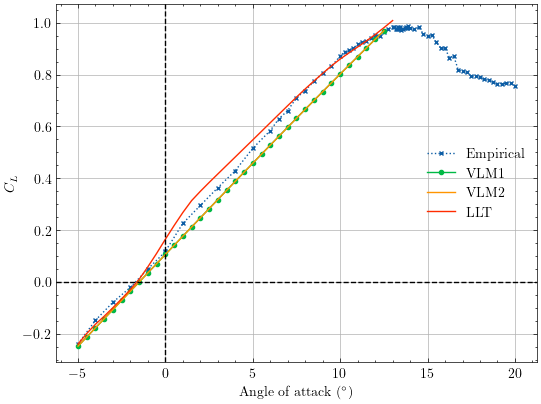

In [84]:
fig()
plt.plot(df_3d.Alpha, C_L, label="Empirical", marker='x', linestyle=':', markersize=3)
plt.plot(vlm1.alpha, vlm1.CL, label='VLM1', marker='o', markersize=3)
plt.plot(vlm2.alpha, vlm1.CL, label='VLM2')
plt.plot(llt.alpha, llt.CL, label='LLT')
plt.grid()
legend()
plt.xlabel("Angle of attack ($^\\circ$)")
plt.ylabel("$C_L$")
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")
plt.savefig("3D C_L vs XFLR.pgf", format="pgf")
plt.show()

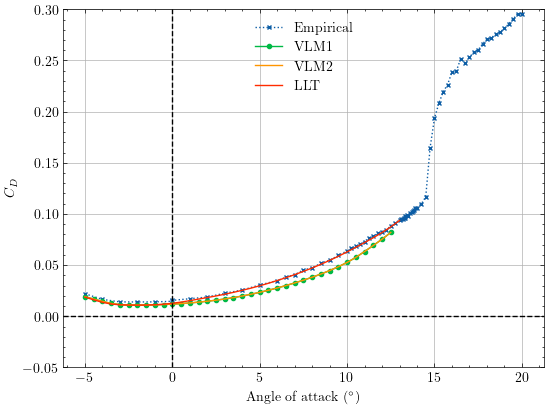

In [112]:
fig()
plt.plot(df_3d.Alpha, C_D, label="Empirical", marker='x', linestyle=':', markersize=3)
plt.plot(vlm1.alpha, vlm1.CD, label='VLM1', marker='o', markersize=3)
plt.plot(vlm2.alpha, vlm1.CD, label='VLM2')
plt.plot(llt.alpha, llt.CD, label='LLT')
plt.grid()
legend()
plt.xlabel("Angle of attack ($^\\circ$)")
plt.ylabel("$C_D$")
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")
plt.savefig("3D C_D vs XFL5.pgf", format="pgf")
plt.ylim(-0.05, 0.3)
plt.show()

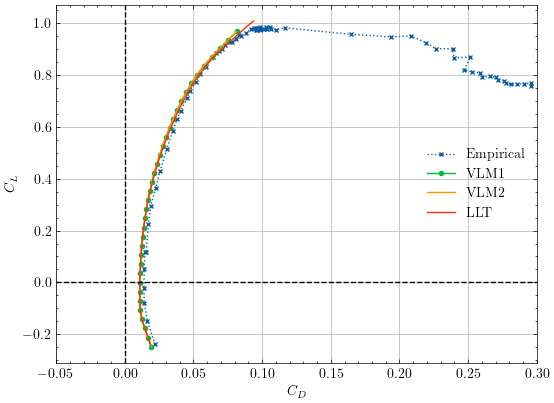

In [113]:
fig()
plt.plot(C_D, C_L, label="Empirical", marker='x', linestyle=':', markersize=3)
plt.plot(vlm1.CD, vlm1.CL, label='VLM1', marker='o', markersize=3)
plt.plot(vlm2.CD, vlm1.CL, label='VLM2')
plt.plot(llt.CD, llt.CL, label='LLT')
plt.grid()
legend()
plt.ylabel("$C_L$")
plt.xlabel("$C_D$")
plt.xlim(-0.05, 0.3)
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")
plt.savefig("3D C_L C_D vs XFL5.pgf", format="pgf")
plt.show()

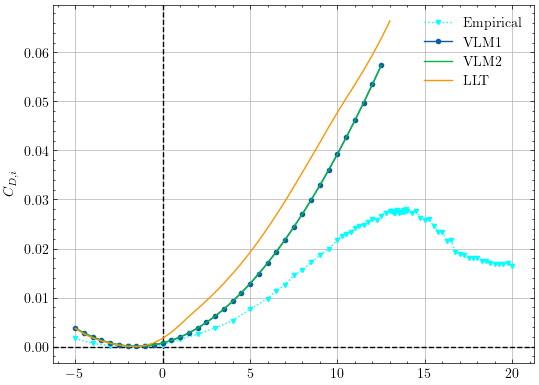

In [108]:
fig(1)

ax1 = plt.gca()

ax1.grid(True)
ax1.axvline(0, color="black", linestyle="--")
ax1.axhline(0, color="black", linestyle="--")

C_ms_c4 = C_ms + C_l / 4

markers = ['x', 'o', 's', '^', 'v', '<', '>', 'd', 'p', 'P', '*', 'h', 'H', '+', 'X', '|', '_']

ax1.plot(df_3d.Alpha, C_d_i, marker='v', linestyle=':', markersize=3, color="cyan", label='Empirical')

plt.plot(vlm1.alpha, vlm1.CDi, label='VLM1', marker='o', markersize=3)
plt.plot(vlm2.alpha, vlm1.CDi, label='VLM2')
plt.plot(llt.alpha, llt.CDi, label='LLT')

ax1.set_ylabel("$C_{D,i}$")

legend()
plt.savefig("2D 3D comp C_D_i.pgf", format="pgf")

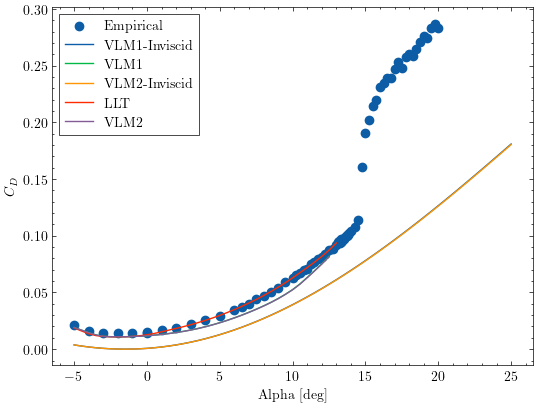

In [12]:
fig()
plt.scatter(df_3d.Alpha, C_D, label="Empirical")
plt.plot(vlm1_invs.alpha, vlm1_invs.CD, label='VLM1-Inviscid')
plt.plot(vlm1.alpha, vlm1.CD, label='VLM1')
plt.plot(vlm2_invs.alpha, vlm2_invs.CD, label='VLM2-Inviscid')
plt.plot(llt.alpha, llt.CD, label='LLT')
plt.plot(vlm2.alpha, vlm2.CD, label='VLM2')
legend()
plt.xlabel("Alpha [deg]")
plt.ylabel("$C_D$")
plt.grid()
plt.show()

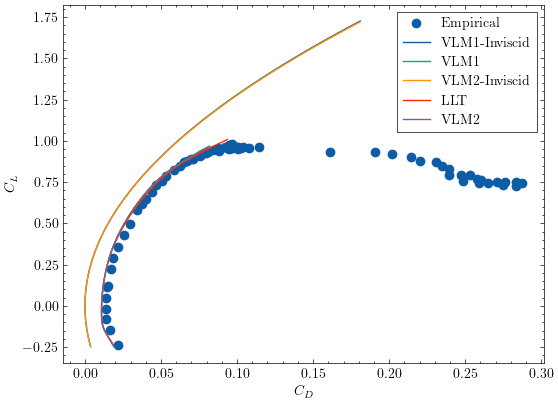

In [13]:
fig()
plt.scatter(C_D, C_L, label="Empirical")
plt.plot(vlm1_invs.CD, vlm1_invs.CL, label='VLM1-Inviscid')
plt.plot(vlm1.CD, vlm1.CL, label='VLM1')
plt.plot(vlm2_invs.CD, vlm2_invs.CL, label='VLM2-Inviscid')
plt.plot(llt.CD, llt.CL, label='LLT')
plt.plot(vlm2.CD, vlm2.CL, label='VLM2')
legend()
plt.xlabel("$C_D$")
plt.ylabel("$C_L$")
plt.grid()
plt.show()